In [1]:
# Create a Spark session (runs locally by default in most notebook setups)
# Ensure Spark uses this notebook's Python interpreter (important on Windows where `python3` may not exist)
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("EnergyProject")
    .config("spark.pyspark.python", sys.executable)
    .config("spark.pyspark.driver.python", sys.executable)
    .config("spark.executorEnv.PYSPARK_PYTHON", sys.executable)
    .config("spark.executorEnv.PYSPARK_DRIVER_PYTHON", sys.executable)
    .getOrCreate()
)

# Reduce Spark logging noise in notebook output
spark.sparkContext.setLogLevel("ERROR")

In [2]:
# Read the uploaded survey dataset (CSV)
df = spark.read.csv("pakistanenergyaccesshouseholdpanelsurveydata.csv", 
                    header=True, inferSchema=True)

# Preview a few useful columns
df.select("Region", "Districts", "Gender", "SEC").show(5, truncate=False)

+------+---------------------+------+-----+
|Region|Districts            |Gender|SEC  |
+------+---------------------+------+-----+
|NULL  |Bahawalnagar District|2     |SEC C|
|NULL  |NULL                 |NULL  |NULL |
|NULL  |Bhakkar District     |2     |SEC D|
|NULL  |NULL                 |NULL  |NULL |
|NULL  |Bhakkar District     |2     |SEC D|
+------+---------------------+------+-----+
only showing top 5 rows


In [3]:
# Inspect schema inferred by Spark
df.printSchema()

root
 |-- Interview type: string (nullable = true)
 |-- Peri Urban/ Rural: string (nullable = true)
 |-- SEC: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Districts: string (nullable = true)
 |-- Cultural Belts: string (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- Household Size: integer (nullable = true)
 |-- Housing type you are living: integer (nullable = true)
 |-- Rooms does the house have : integer (nullable = true)
 |-- House rented or owned: integer (nullable = true)
 |-- household composition: integer (nullable = true)
 |-- Education of Head of household: integer (nullable = true)
 |-- Occupation of head of household: integer (nullable = true)
 |-- Do you expect the number of household members living in your home to change in the next 1-2 years?: integer (nullable = true)
 |-- Are you planning to increase the size of your home by adding rooms or spaces that will need lighting in the next 1-2 years?: integer (nullable = true)
 |-- Do you o

In [4]:
df.select("Region").limit(10000).groupBy("Region").count().show()

+-------+-----+
| Region|count|
+-------+-----+
|Karachi| 1662|
|      5|    1|
| Quetta|  456|
|   NULL| 7881|
+-------+-----+



In [5]:
df.filter(df["Is your household connected to the National or Local Mini-Grid?"] == 1).select("Region", "Districts", "Is your household connected to the National or Local Mini-Grid?").limit(20).show(truncate=False)

+------+---------------------+---------------------------------------------------------------+
|Region|Districts            |Is your household connected to the National or Local Mini-Grid?|
+------+---------------------+---------------------------------------------------------------+
|NULL  |Bahawalnagar District|1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bahawalnagar District|1                                                              |
|NULL  |Bhakkar District     |1                                                              |
|NULL  |Bhakkar District     |1                   

In [6]:
df.limit(10000).createOrReplaceTempView("energy")
spark.sql("SELECT Region, COUNT(*) AS count FROM energy GROUP BY Region").show()

+-------+-----+
| Region|count|
+-------+-----+
|Karachi| 1662|
|      5|    1|
| Quetta|  456|
|   NULL| 7881|
+-------+-----+



In [7]:
# -----------------------------
# Project Deliverables
# - ETL pipeline (extract, transform, load)
# - map / filter / reduce / groupBy examples (RDD + DataFrame)
# - Spark SQL + performance comparison vs pure Python
# - Performance graphs (rendered as ASCII so it works without extra plotting libraries)
# -----------------------------

from pyspark.sql import functions as F
import os
import time
import csv
from collections import defaultdict

DATA_PATH = "pakistanenergyaccesshouseholdpanelsurveydata.csv"

# Column name as it exists in the uploaded dataset
CONNECTED_COL = "Is your household connected to the National or Local Mini-Grid?"

OUTPUT_DIR = "etl_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset:", os.path.abspath(DATA_PATH))
print("Output dir:", os.path.abspath(OUTPUT_DIR))

Dataset: C:\Users\mariy\OneDrive\Desktop\energy_project\pakistanenergyaccesshouseholdpanelsurveydata.csv
Output dir: C:\Users\mariy\OneDrive\Desktop\energy_project\etl_output


In [8]:
# Basic transformations: select a few columns, trim strings, cast types
df_etl = (
    df.select(
        F.col("Region").alias("region_raw"),
        F.col("Districts").alias("district_raw"),
        F.col(CONNECTED_COL).alias("connected_raw"),
    )
    .withColumn("region", F.trim(F.col("region_raw")))
    .withColumn("district", F.trim(F.col("district_raw")))
    .withColumn("connected_to_grid", F.col("connected_raw").cast("int"))
    .drop("region_raw", "district_raw", "connected_raw")
)

# Fill missing region/district values so grouping is stable
df_etl = (
    df_etl
    .withColumn(
        "region",
        F.when(F.col("region").isNull() | (F.col("region") == ""), F.lit("UNKNOWN")).otherwise(F.col("region")),
    )
    .withColumn(
        "district",
        F.when(F.col("district").isNull() | (F.col("district") == ""), F.lit("UNKNOWN")).otherwise(F.col("district")),
    )
)

# Cache for repeated use in ETL + benchmarking
df_etl.cache()
df_etl.count()

df_etl.show(10, truncate=False)
df_etl.groupBy("connected_to_grid").count().show()


+-------+---------------------+-----------------+
|region |district             |connected_to_grid|
+-------+---------------------+-----------------+
|UNKNOWN|Bahawalnagar District|1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
|UNKNOWN|Bhakkar District     |1                |
|UNKNOWN|UNKNOWN              |NULL             |
+-------+---------------------+-----------------+
only showing top 10 rows


+-----------------+-----+
|connected_to_grid|count|
+-----------------+-----+
|             NULL| 8463|
|                1| 7011|
|                2| 1451|
+-----------------+-----+



In [9]:
# ETL Pipeline (DataFrame API)
# Extract: df_etl (already built)
# Transform: filter connected households + groupBy to aggregate
df_connected = df_etl.filter(F.col("connected_to_grid") == 1)

df_counts_df = (
    df_connected
    .groupBy("region")
    .count()
    .orderBy(F.desc("count"))
)

df_counts_df.show(50, truncate=False)

# Load: write the aggregated output to disk
# On some Windows setups Spark's Hadoop writer can fail without winutils/hadoop native libs.
# Since this aggregated dataset is small, we collect and write using pure Python for portability.
import json

output_csv = os.path.join(OUTPUT_DIR, "connected_counts_by_region.csv")
output_jsonl = os.path.join(OUTPUT_DIR, "connected_counts_by_region.jsonl")

rows = df_counts_df.collect()

with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["region", "count"])
    for r in rows:
        writer.writerow([r["region"], int(r["count"])])

with open(output_jsonl, "w", encoding="utf-8") as f:
    for r in rows:
        f.write(json.dumps({"region": r["region"], "count": int(r["count"])}) + "\n")

print("Wrote CSV to:", os.path.abspath(output_csv))
print("Wrote JSONL to:", os.path.abspath(output_jsonl))


+--------+-----+
|region  |count|
+--------+-----+
|UNKNOWN |2656 |
|Multan  |1485 |
|Quetta  |1183 |
|Karachi |985  |
|Peshawar|702  |
+--------+-----+



Wrote CSV to: C:\Users\mariy\OneDrive\Desktop\energy_project\etl_output\connected_counts_by_region.csv
Wrote JSONL to: C:\Users\mariy\OneDrive\Desktop\energy_project\etl_output\connected_counts_by_region.jsonl


In [10]:
# Map / Filter / Reduce / GroupBy using the DataFrame API (no Python workers required)
# This is more stable on Windows environments where Spark may not find `python3`.

# map: derive a numeric flag we can aggregate
df_mapped = df_etl.select(
    F.col("region"),
    (F.col("connected_to_grid") == 1).cast("int").alias("is_connected"),
)

# filter: keep only connected households
df_filtered = df_mapped.filter(F.col("is_connected") == 1)

# groupBy + reduce: sum the flag per region
df_counts_mfrg = (
    df_filtered
    .groupBy("region")
    .agg(F.sum("is_connected").alias("count"))
    .orderBy(F.desc("count"))
)

df_counts_mfrg.show(50, truncate=False)

# reduce (global): total connected households across all regions
total_connected = df_counts_mfrg.agg(F.sum("count").alias("total_connected")).collect()[0]["total_connected"]
print("Total connected households (all regions):", int(total_connected) if total_connected is not None else 0)


+--------+-----+
|region  |count|
+--------+-----+
|UNKNOWN |2656 |
|Multan  |1485 |
|Quetta  |1183 |
|Karachi |985  |
|Peshawar|702  |
+--------+-----+



Total connected households (all regions): 7011


In [11]:
# Spark SQL version + validation vs DataFrame result
df_etl.createOrReplaceTempView("energy_etl")

df_counts_sql = spark.sql(
    """
    SELECT
      region,
      COUNT(*) AS count
    FROM energy_etl
    WHERE connected_to_grid = 1
    GROUP BY region
    ORDER BY count DESC
    """
)

df_counts_sql.show(50, truncate=False)

# Validate: DataFrame aggregation == SQL aggregation
df_left = df_counts_df.select(F.col("region"), F.col("count").alias("count_df"))
df_right = df_counts_sql.select(F.col("region"), F.col("count").alias("count_sql"))

diff = (
    df_left.join(df_right, on="region", how="full")
    .fillna(0, subset=["count_df", "count_sql"])
    .withColumn("diff", F.col("count_df") - F.col("count_sql"))
    .filter(F.col("diff") != 0)
)

print("Mismatched regions (should be 0 rows):")
diff.show(truncate=False)


+--------+-----+
|region  |count|
+--------+-----+
|UNKNOWN |2656 |
|Multan  |1485 |
|Quetta  |1183 |
|Karachi |985  |
|Peshawar|702  |
+--------+-----+



Mismatched regions (should be 0 rows):


+------+--------+---------+----+
|region|count_df|count_sql|diff|
+------+--------+---------+----+
+------+--------+---------+----+



In [12]:
# Performance comparison: Spark DataFrame vs Spark SQL vs pure Python
# Notes:
# - We benchmark on increasing row limits so the notebook stays responsive.
# - Each Spark benchmark triggers an action (count) to force execution.

def time_spark_dataframe(n_rows: int) -> float:
    t0 = time.perf_counter()
    (
        df_etl.limit(n_rows)
        .filter(F.col("connected_to_grid") == 1)
        .groupBy("region")
        .count()
        .count()
    )
    return time.perf_counter() - t0

def time_spark_sql(n_rows: int) -> float:
    t0 = time.perf_counter()
    df_etl.limit(n_rows).createOrReplaceTempView("energy_bench")
    spark.sql("SELECT region, COUNT(*) AS c FROM energy_bench WHERE connected_to_grid = 1 GROUP BY region").count()
    return time.perf_counter() - t0

def time_pure_python(n_rows: int) -> float:
    t0 = time.perf_counter()
    counts = defaultdict(int)
    with open(DATA_PATH, newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        header = next(reader)
        try:
            region_idx = header.index("Region")
            conn_idx = header.index(CONNECTED_COL)
        except ValueError as e:
            raise ValueError(f"Required columns not found in CSV header: {e}")

        for i, row in enumerate(reader, start=1):
            if i > n_rows:
                break
            if len(row) <= max(region_idx, conn_idx):
                continue

            region = (row[region_idx] or "UNKNOWN").strip() or "UNKNOWN"
            conn_raw = (row[conn_idx] or "").strip()
            if conn_raw == "1":
                counts[region] += 1

    return time.perf_counter() - t0

# Pick increasing sizes (adjustable)
sizes = [10_000, 50_000, 100_000]

results = []
for n in sizes:
    results.append({
        "rows": n,
        "spark_dataframe_s": time_spark_dataframe(n),
        "spark_sql_s": time_spark_sql(n),
        "pure_python_s": time_pure_python(n),
    })

results


[{'rows': 10000,
  'spark_dataframe_s': 0.507997400000022,
  'spark_sql_s': 0.3868886999998722,
  'pure_python_s': 0.3488231999999698},
 {'rows': 50000,
  'spark_dataframe_s': 0.3457491999997728,
  'spark_sql_s': 0.38999469999998837,
  'pure_python_s': 0.20292150000022957},
 {'rows': 100000,
  'spark_dataframe_s': 0.330631099999664,
  'spark_sql_s': 0.32502710000062507,
  'pure_python_s': 0.3216704000005848}]

In [13]:
# Performance graphs (ASCII)
# This avoids extra plotting dependencies and still provides clear visuals.

def ascii_bar(value: float, max_value: float, width: int = 40) -> str:
    if max_value <= 0:
        return ""
    filled = int(round((value / max_value) * width))
    filled = max(0, min(width, filled))
    return "█" * filled + " " * (width - filled)

def print_ascii_chart(results_list):
    max_time = max(max(r["spark_dataframe_s"], r["spark_sql_s"], r["pure_python_s"]) for r in results_list)
    print("rows\tmethod\t\tseconds\tchart")
    for r in results_list:
        for key, label in [
            ("spark_dataframe_s", "Spark DataFrame"),
            ("spark_sql_s", "Spark SQL"),
            ("pure_python_s", "Pure Python"),
        ]:
            v = r[key]
            bar = ascii_bar(v, max_time)
            print(f"{r['rows']}\t{label:<14}\t{v:0.4f}\t{bar}")

print_ascii_chart(results)

# Also print a compact table
for r in results:
    print(f"n={r['rows']}: df={r['spark_dataframe_s']:.4f}s, sql={r['spark_sql_s']:.4f}s, py={r['pure_python_s']:.4f}s")


rows	method		seconds	chart
10000	Spark DataFrame	0.5080	████████████████████████████████████████
10000	Spark SQL     	0.3869	██████████████████████████████          
10000	Pure Python   	0.3488	███████████████████████████             
50000	Spark DataFrame	0.3457	███████████████████████████             
50000	Spark SQL     	0.3900	███████████████████████████████         
50000	Pure Python   	0.2029	████████████████                        
100000	Spark DataFrame	0.3306	██████████████████████████              
100000	Spark SQL     	0.3250	██████████████████████████              
100000	Pure Python   	0.3217	█████████████████████████               
n=10000: df=0.5080s, sql=0.3869s, py=0.3488s
n=50000: df=0.3457s, sql=0.3900s, py=0.2029s
n=100000: df=0.3306s, sql=0.3250s, py=0.3217s


# Additional Analysis + Interactive Visualizations

This section adds a few extra perspectives on the dataset (region, district, gender, SEC), and interactive performance charts.

Interactive charts are rendered using Vega-Lite (embedded via CDN) so you get tooltips, zooming/panning (where enabled), and legend-based filtering without installing extra Python plotting libraries. If your notebook environment blocks inline scripts, the code also attempts to render charts via the Vega-Lite MIME bundle.


In [14]:
from pyspark.sql import functions as F
import json
import uuid
from IPython.display import HTML, display

def connection_status_expr(col_name: str):
    c = F.col(col_name)
    return (
        F.when(c == 1, F.lit("Connected"))
        .when(c == 2, F.lit("Not connected"))
        .otherwise(F.lit("Unknown/NA"))
    )

top_n = 10

def safe_int(col):
    s = F.trim(col.cast("string"))
    return F.when(s.rlike("^[0-9]+$"), s.cast("int")).otherwise(F.lit(None).cast("int"))

region_connected_top = (
    df_etl
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .filter(F.col("connection_status") == "Connected")
    .groupBy("region")
    .count()
    .orderBy(F.desc("count"))
    .limit(top_n)
)

district_connected_top = (
    df_etl
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .filter(F.col("connection_status") == "Connected")
    .groupBy("district")
    .count()
    .orderBy(F.desc("count"))
    .limit(top_n)
)

overall_connection = (
    df_etl
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .groupBy("connection_status")
    .count()
)

gender_connection = (
    df.select(
        F.when(F.col("Gender").isNull() | (F.trim(F.col("Gender").cast("string")) == ""), F.lit("UNKNOWN")).otherwise(F.col("Gender").cast("string")).alias("gender"),
        safe_int(F.col(CONNECTED_COL)).alias("connected_to_grid"),
    )
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .groupBy("gender", "connection_status")
    .count()
)

sec_connection = (
    df.select(
        F.when(F.col("SEC").isNull() | (F.trim(F.col("SEC").cast("string")) == ""), F.lit("UNKNOWN")).otherwise(F.col("SEC").cast("string")).alias("sec"),
        safe_int(F.col(CONNECTED_COL)).alias("connected_to_grid"),
    )
    .withColumn("connection_status", connection_status_expr("connected_to_grid"))
    .groupBy("sec", "connection_status")
    .count()
)

def rows_to_dicts(rows):
    out = []
    for r in rows:
        out.append({k: (int(r[k]) if isinstance(r[k], (int, float)) and k in {"count"} else r[k]) for k in r.asDict().keys()})
    return out

data_region = [{"region": r["region"], "count": int(r["count"])} for r in region_connected_top.collect()]
data_district = [{"district": r["district"], "count": int(r["count"])} for r in district_connected_top.collect()]
data_overall = [{"connection_status": r["connection_status"], "count": int(r["count"])} for r in overall_connection.collect()]
data_gender = [{"gender": r["gender"], "connection_status": r["connection_status"], "count": int(r["count"])} for r in gender_connection.collect()]
data_sec = [{"sec": r["sec"], "connection_status": r["connection_status"], "count": int(r["count"])} for r in sec_connection.collect()]

perf_long = []
speedup_long = []
for r in results:
    n = int(r["rows"])
    baseline = float(r["pure_python_s"])
    for key, label in [
        ("spark_dataframe_s", "Spark DataFrame"),
        ("spark_sql_s", "Spark SQL"),
        ("pure_python_s", "Pure Python"),
    ]:
        sec = float(r[key])
        perf_long.append({"rows": n, "method": label, "seconds": sec, "rows_per_sec": (n / sec) if sec > 0 else None})
    for key, label in [("spark_dataframe_s", "Spark DataFrame"), ("spark_sql_s", "Spark SQL")]:
        sec = float(r[key])
        speedup_long.append({"rows": n, "method": label, "speedup_vs_python": (baseline / sec) if sec > 0 else None})

print("Prepared datasets for interactive charts:")
print("- region top:", len(data_region))
print("- district top:", len(data_district))
print("- overall connection:", len(data_overall))
print("- gender x connection:", len(data_gender))
print("- SEC x connection:", len(data_sec))
print("- performance points:", len(perf_long))


Prepared datasets for interactive charts:
- region top: 5
- district top: 10
- overall connection: 3
- gender x connection: 6
- SEC x connection: 12
- performance points: 9


Saved: etl_output\plots\top_regions_connected.png
Saved: etl_output\plots\top_regions_connected.jpg


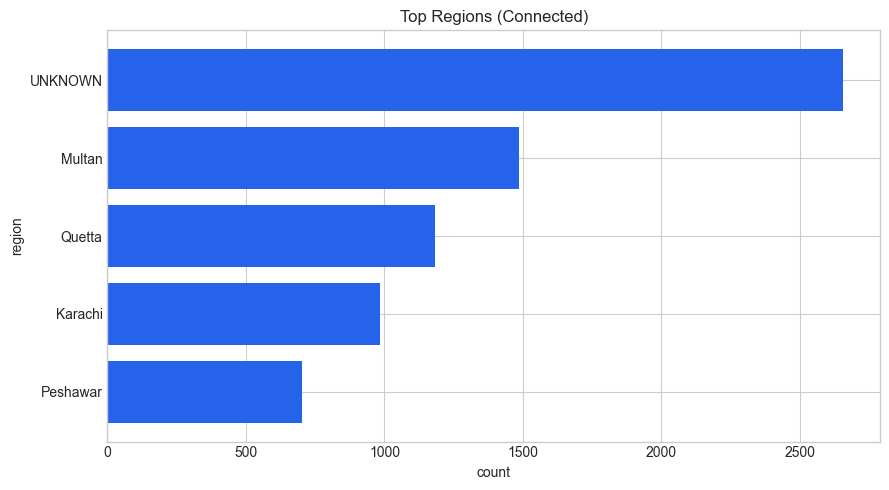

Saved: etl_output\plots\top_districts_connected.png
Saved: etl_output\plots\top_districts_connected.jpg


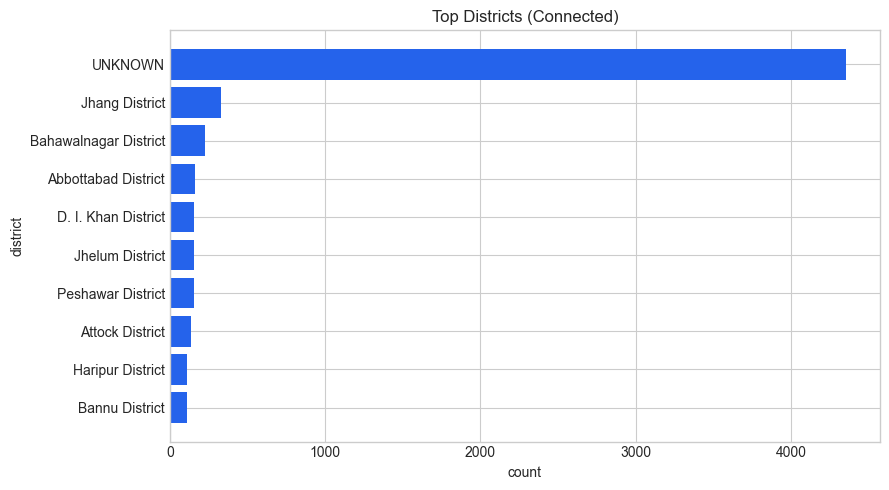

Saved: etl_output\plots\overall_connection_status.png
Saved: etl_output\plots\overall_connection_status.jpg


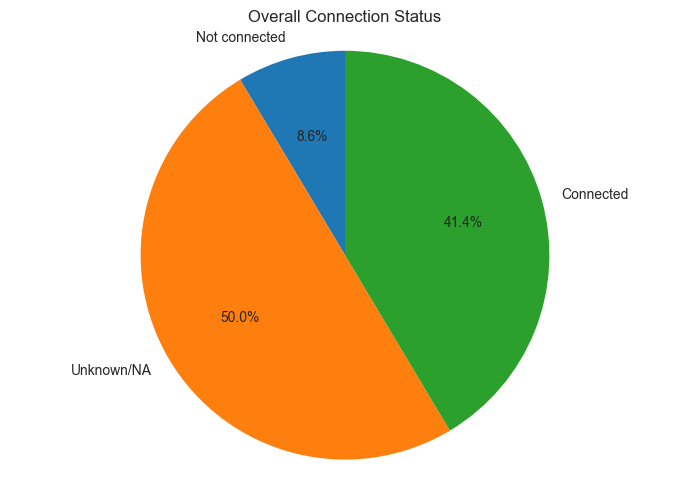

Saved: etl_output\plots\connection_by_gender.png
Saved: etl_output\plots\connection_by_gender.jpg


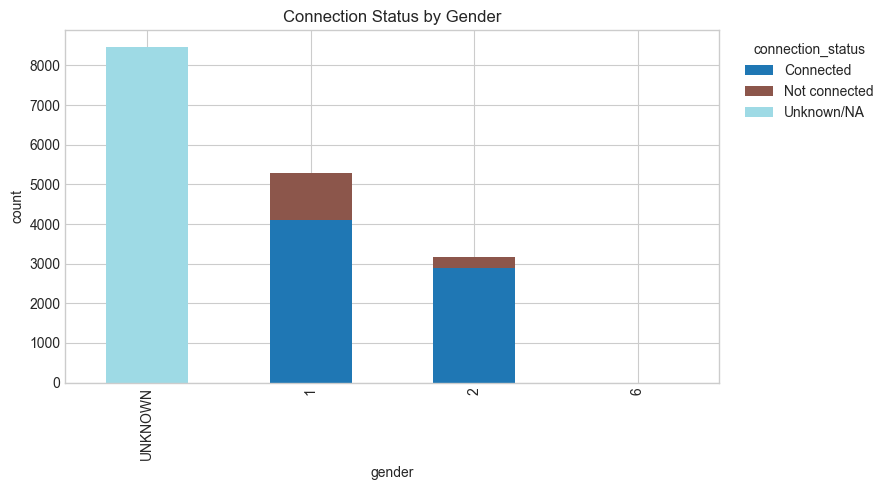

Saved: etl_output\plots\connection_by_sec.png
Saved: etl_output\plots\connection_by_sec.jpg


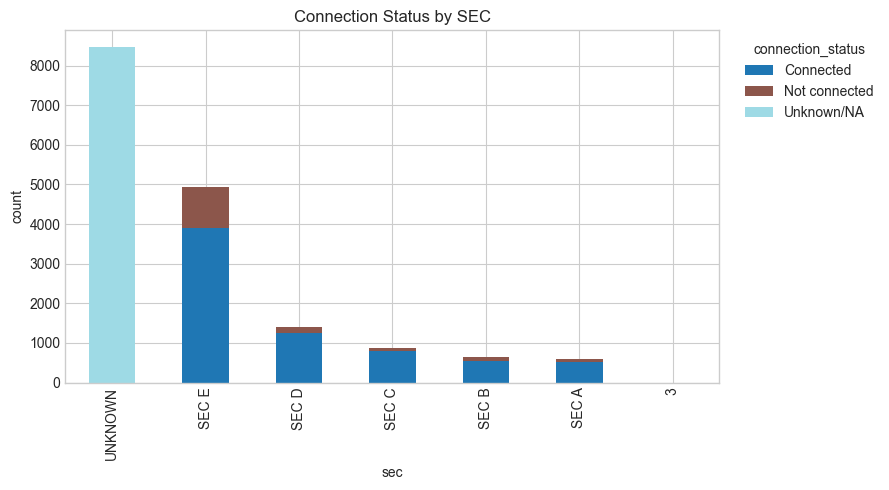

Saved: etl_output\plots\performance_seconds_vs_rows.png
Saved: etl_output\plots\performance_seconds_vs_rows.jpg


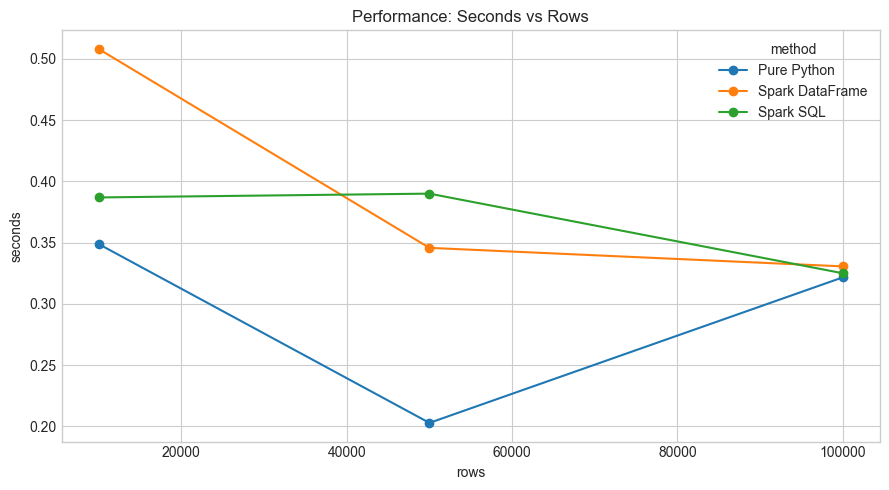

Saved: etl_output\plots\performance_speedup_vs_python.png
Saved: etl_output\plots\performance_speedup_vs_python.jpg


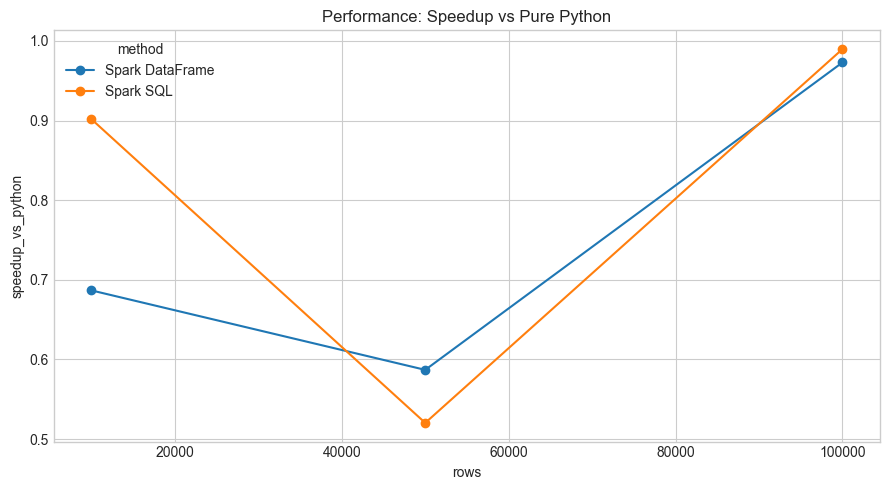

In [15]:
import json
import uuid
from pyspark.sql import functions as F
from IPython.display import HTML, display

def _safe_show_vegalite(spec: dict):
    try:
        display({"application/vnd.vegalite.v5+json": spec}, raw=True)
    except Exception:
        display(spec)

def _connection_status_expr(c):
    return (
        F.when(c == 1, F.lit("Connected"))
        .when(c == 2, F.lit("Not connected"))
        .otherwise(F.lit("Unknown/NA"))
    )

def safe_int(col):
    s = F.trim(col.cast("string"))
    return F.when(s.rlike("^[0-9]+$"), s.cast("int")).otherwise(F.lit(None).cast("int"))

if "top_n" not in globals():
    top_n = 10

need_datasets = any(
    k not in globals()
    for k in [
        "data_region",
        "data_district",
        "data_overall",
        "data_gender",
        "data_sec",
        "perf_long",
        "speedup_long",
    ]
)

if need_datasets:
    try:
        region_connected_top = (
            df_etl
            .withColumn("connection_status", _connection_status_expr(F.col("connected_to_grid")))
            .filter(F.col("connection_status") == "Connected")
            .groupBy("region")
            .count()
            .orderBy(F.desc("count"))
            .limit(int(top_n))
        )

        district_connected_top = (
            df_etl
            .withColumn("connection_status", _connection_status_expr(F.col("connected_to_grid")))
            .filter(F.col("connection_status") == "Connected")
            .groupBy("district")
            .count()
            .orderBy(F.desc("count"))
            .limit(int(top_n))
        )

        overall_connection = (
            df_etl
            .withColumn("connection_status", _connection_status_expr(F.col("connected_to_grid")))
            .groupBy("connection_status")
            .count()
        )

        gender_connection = (
            df.select(
                F.when(F.col("Gender").isNull() | (F.trim(F.col("Gender").cast("string")) == ""), F.lit("UNKNOWN")).otherwise(F.col("Gender").cast("string")).alias("gender"),
                safe_int(F.col(CONNECTED_COL)).alias("connected_to_grid"),
            )
            .withColumn("connection_status", _connection_status_expr(F.col("connected_to_grid")))
            .groupBy("gender", "connection_status")
            .count()
        )

        sec_connection = (
            df.select(
                F.when(F.col("SEC").isNull() | (F.trim(F.col("SEC").cast("string")) == ""), F.lit("UNKNOWN")).otherwise(F.col("SEC").cast("string")).alias("sec"),
                safe_int(F.col(CONNECTED_COL)).alias("connected_to_grid"),
            )
            .withColumn("connection_status", _connection_status_expr(F.col("connected_to_grid")))
            .groupBy("sec", "connection_status")
            .count()
        )

        data_region = [{"region": r["region"], "count": int(r["count"])} for r in region_connected_top.collect()]
        data_district = [{"district": r["district"], "count": int(r["count"])} for r in district_connected_top.collect()]
        data_overall = [{"connection_status": r["connection_status"], "count": int(r["count"])} for r in overall_connection.collect()]
        data_gender = [{"gender": r["gender"], "connection_status": r["connection_status"], "count": int(r["count"])} for r in gender_connection.collect()]
        data_sec = [{"sec": r["sec"], "connection_status": r["connection_status"], "count": int(r["count"])} for r in sec_connection.collect()]

        perf_long = []
        speedup_long = []
        if "results" in globals() and isinstance(results, list):
            for r in results:
                n = int(r["rows"])
                baseline = float(r["pure_python_s"])
                for key, label in [
                    ("spark_dataframe_s", "Spark DataFrame"),
                    ("spark_sql_s", "Spark SQL"),
                    ("pure_python_s", "Pure Python"),
                ]:
                    sec = float(r[key])
                    perf_long.append({"rows": n, "method": label, "seconds": sec, "rows_per_sec": (n / sec) if sec > 0 else None})
                for key, label in [("spark_dataframe_s", "Spark DataFrame"), ("spark_sql_s", "Spark SQL")]:
                    sec = float(r[key])
                    speedup_long.append({"rows": n, "method": label, "speedup_vs_python": (baseline / sec) if sec > 0 else None})
    except Exception as e:
        print("Interactive chart data prep failed:", e)
        data_region, data_district, data_overall, data_gender, data_sec = [], [], [], [], []
        perf_long, speedup_long = [], []
def vega_html(charts_by_id: dict) -> HTML:
    libs = """
<script src=\"https://cdn.jsdelivr.net/npm/vega@5\"></script>
<script src=\"https://cdn.jsdelivr.net/npm/vega-lite@5\"></script>
<script src=\"https://cdn.jsdelivr.net/npm/vega-embed@6\"></script>
    """

    css = """
<style>
  .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 18px; }
  .card { border: 1px solid #e5e7eb; border-radius: 10px; padding: 12px; box-shadow: 0 1px 2px rgba(0,0,0,0.04); }
  .title { font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial; font-weight: 700; font-size: 16px; margin: 0 0 8px 0; }
  .note { font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial; font-size: 12px; color: #6b7280; margin: 0 0 10px 0; }
  .full { grid-column: 1 / -1; }
</style>
    """

    container_id = f"dash_{uuid.uuid4().hex}"
    divs = []
    for chart_id, meta in charts_by_id.items():
        divs.append(f"<div class=\"card {meta.get('class','')}\"><p class=\"title\">{meta['title']}</p><p class=\"note\">{meta['note']}</p><div id=\"{container_id}_{chart_id}\"></div></div>")

    js = """
<script>
(function(){
  const charts = CHARTS_JSON;
  for (const [chartId, meta] of Object.entries(charts)) {
    const target = `#${CONTAINER_ID}_${chartId}`;
    vegaEmbed(target, meta.spec, { actions: true });
  }
})();
</script>
    """

    charts_payload = {}
    for chart_id, meta in charts_by_id.items():
        charts_payload[chart_id] = {"spec": meta["spec"]}

    html = libs + css + f"<div class=\"grid\" id=\"{container_id}\">" + "".join(divs) + "</div>"
    html += js.replace("CHARTS_JSON", json.dumps(charts_payload)).replace("CONTAINER_ID", container_id)
    return HTML(html)

spec_region = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "Top regions by connected households",
    "data": {"values": data_region},
    "mark": {"type": "bar", "cornerRadiusEnd": 4},
    "encoding": {
        "y": {"field": "region", "type": "nominal", "sort": "-x", "title": "Region"},
        "x": {"field": "count", "type": "quantitative", "title": "Connected households"},
        "tooltip": [
            {"field": "region", "type": "nominal"},
            {"field": "count", "type": "quantitative"},
        ],
    },
    "width": "container",
    "height": 260,
}

spec_district = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "Top districts by connected households",
    "data": {"values": data_district},
    "mark": {"type": "bar", "cornerRadiusEnd": 4},
    "encoding": {
        "y": {"field": "district", "type": "nominal", "sort": "-x", "title": "District"},
        "x": {"field": "count", "type": "quantitative", "title": "Connected households"},
        "tooltip": [
            {"field": "district", "type": "nominal"},
            {"field": "count", "type": "quantitative"},
        ],
    },
    "width": "container",
    "height": 260,
}

spec_overall = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "Overall connection status distribution",
    "data": {"values": data_overall},
    "mark": {"type": "arc", "innerRadius": 55},
    "encoding": {
        "theta": {"field": "count", "type": "quantitative"},
        "color": {"field": "connection_status", "type": "nominal", "title": "Status"},
        "tooltip": [
            {"field": "connection_status", "type": "nominal"},
            {"field": "count", "type": "quantitative"},
        ],
    },
    "width": "container",
    "height": 260,
}

spec_gender = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "Connection status by gender",
    "data": {"values": data_gender},
    "mark": {"type": "bar"},
    "encoding": {
        "x": {"field": "gender", "type": "nominal", "title": "Gender"},
        "y": {"field": "count", "type": "quantitative", "title": "Households"},
        "color": {"field": "connection_status", "type": "nominal", "title": "Status"},
        "tooltip": [
            {"field": "gender", "type": "nominal"},
            {"field": "connection_status", "type": "nominal"},
            {"field": "count", "type": "quantitative"},
        ],
    },
    "width": "container",
    "height": 260,
}

spec_sec = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "Connection status by SEC",
    "data": {"values": data_sec},
    "mark": {"type": "bar"},
    "encoding": {
        "x": {"field": "sec", "type": "nominal", "title": "SEC"},
        "y": {"field": "count", "type": "quantitative", "title": "Households"},
        "color": {"field": "connection_status", "type": "nominal", "title": "Status"},
        "tooltip": [
            {"field": "sec", "type": "nominal"},
            {"field": "connection_status", "type": "nominal"},
            {"field": "count", "type": "quantitative"},
        ],
    },
    "width": "container",
    "height": 260,
}

spec_perf_line = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "Runtime vs rows",
    "data": {"values": perf_long},
    "mark": {"type": "line", "point": True},
    "encoding": {
        "x": {"field": "rows", "type": "quantitative", "title": "Rows (limit n)"},
        "y": {"field": "seconds", "type": "quantitative", "title": "Seconds"},
        "color": {"field": "method", "type": "nominal", "title": "Method"},
        "tooltip": [
            {"field": "rows", "type": "quantitative"},
            {"field": "method", "type": "nominal"},
            {"field": "seconds", "type": "quantitative", "format": ".4f"},
        ],
    },
    "width": "container",
    "height": 260,
}

spec_speedup = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "Speedup vs Pure Python (higher is better)",
    "data": {"values": speedup_long},
    "mark": {"type": "line", "point": True},
    "encoding": {
        "x": {"field": "rows", "type": "quantitative", "title": "Rows (limit n)"},
        "y": {"field": "speedup_vs_python", "type": "quantitative", "title": "Speedup (Python / method)"},
        "color": {"field": "method", "type": "nominal", "title": "Method"},
        "tooltip": [
            {"field": "rows", "type": "quantitative"},
            {"field": "method", "type": "nominal"},
            {"field": "speedup_vs_python", "type": "quantitative", "format": ".2f"},
        ],
    },
    "width": "container",
    "height": 260,
}

spec_throughput = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "Throughput (rows/sec)",
    "data": {"values": perf_long},
    "mark": {"type": "bar"},
    "encoding": {
        "x": {"field": "rows", "type": "ordinal", "title": "Rows (limit n)"},
        "y": {"field": "rows_per_sec", "type": "quantitative", "title": "Rows / second"},
        "color": {"field": "method", "type": "nominal", "title": "Method"},
        "tooltip": [
            {"field": "rows", "type": "quantitative"},
            {"field": "method", "type": "nominal"},
            {"field": "rows_per_sec", "type": "quantitative", "format": ".0f"},
        ],
    },
    "width": "container",
    "height": 260,
}

charts = {
    "region": {"title": f"Top {top_n} Regions (Connected)", "note": "Hover for tooltips. Sorted by count.", "spec": spec_region, "class": ""},
    "district": {"title": f"Top {top_n} Districts (Connected)", "note": "Hover for tooltips. Sorted by count.", "spec": spec_district, "class": ""},
    "overall": {"title": "Overall Connection Status", "note": "Donut chart distribution.", "spec": spec_overall, "class": ""},
    "gender": {"title": "Connection Status by Gender", "note": "Stacked bars by status.", "spec": spec_gender, "class": ""},
    "sec": {"title": "Connection Status by SEC", "note": "Stacked bars by status.", "spec": spec_sec, "class": ""},
    "perf": {"title": "Performance: Seconds vs Rows", "note": "Line chart by method.", "spec": spec_perf_line, "class": "full"},
    "speedup": {"title": "Performance: Speedup vs Pure Python", "note": "Higher is better.", "spec": spec_speedup, "class": "full"},
    "throughput": {"title": "Performance: Throughput (rows/sec)", "note": "Higher is better.", "spec": spec_throughput, "class": "full"},
}

display(vega_html(charts))

for chart_id in ["region", "district", "overall", "gender", "sec", "perf", "speedup", "throughput"]:
    _safe_show_vegalite(charts[chart_id]["spec"])

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plots_dir = os.path.join(OUTPUT_DIR if "OUTPUT_DIR" in globals() else os.path.join(os.getcwd(), "etl_output"), "plots")
os.makedirs(plots_dir, exist_ok=True)

def _save_fig(fig, name: str):
    png_path = os.path.join(plots_dir, f"{name}.png")
    jpg_path = os.path.join(plots_dir, f"{name}.jpg")
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    try:
        im = Image.open(png_path).convert("RGBA")
        bg = Image.new("RGB", im.size, (255, 255, 255))
        bg.paste(im, mask=im.split()[3])
        bg.save(jpg_path, quality=95)
    except Exception:
        fig.savefig(jpg_path, dpi=180, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", jpg_path)

def _barh(values, label_key: str, value_key: str, title: str, filename: str):
    if not values:
        print("No data for", filename)
        return
    dfp = pd.DataFrame(values)
    dfp = dfp.sort_values(value_key, ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(dfp[label_key], dfp[value_key], color="#2563eb")
    ax.set_title(title)
    ax.set_xlabel(value_key)
    ax.set_ylabel(label_key)
    fig.tight_layout()
    _save_fig(fig, filename)
    plt.show()

def _stacked_bar(values, index_key: str, columns_key: str, values_key: str, title: str, filename: str):
    if not values:
        print("No data for", filename)
        return
    dfp = pd.DataFrame(values)
    pivot = dfp.pivot_table(index=index_key, columns=columns_key, values=values_key, aggfunc="sum", fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(9, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_title(title)
    ax.set_xlabel(index_key)
    ax.set_ylabel(values_key)
    ax.legend(title=columns_key, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    _save_fig(fig, filename)
    plt.show()

def _pie(values, label_key: str, value_key: str, title: str, filename: str):
    if not values:
        print("No data for", filename)
        return
    dfp = pd.DataFrame(values)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.pie(dfp[value_key], labels=dfp[label_key], autopct="%1.1f%%", startangle=90)
    ax.set_title(title)
    ax.axis("equal")
    fig.tight_layout()
    _save_fig(fig, filename)
    plt.show()

def _perf_lines(perf_values, x_key: str, y_key: str, series_key: str, title: str, filename: str):
    if not perf_values:
        print("No data for", filename)
        return
    dfp = pd.DataFrame(perf_values)
    fig, ax = plt.subplots(figsize=(9, 5))
    for name, g in dfp.groupby(series_key):
        g = g.sort_values(x_key)
        ax.plot(g[x_key], g[y_key], marker="o", label=str(name))
    ax.set_title(title)
    ax.set_xlabel(x_key)
    ax.set_ylabel(y_key)
    ax.legend(title=series_key)
    fig.tight_layout()
    _save_fig(fig, filename)
    plt.show()

_barh(data_region if "data_region" in globals() else [], "region", "count", "Top Regions (Connected)", "top_regions_connected")
_barh(data_district if "data_district" in globals() else [], "district", "count", "Top Districts (Connected)", "top_districts_connected")
_pie(data_overall if "data_overall" in globals() else [], "connection_status", "count", "Overall Connection Status", "overall_connection_status")
_stacked_bar(data_gender if "data_gender" in globals() else [], "gender", "connection_status", "count", "Connection Status by Gender", "connection_by_gender")
_stacked_bar(data_sec if "data_sec" in globals() else [], "sec", "connection_status", "count", "Connection Status by SEC", "connection_by_sec")
_perf_lines(perf_long if "perf_long" in globals() else [], "rows", "seconds", "method", "Performance: Seconds vs Rows", "performance_seconds_vs_rows")
_perf_lines(speedup_long if "speedup_long" in globals() else [], "rows", "speedup_vs_python", "method", "Performance: Speedup vs Pure Python", "performance_speedup_vs_python")


# Final Report: Energy Access Survey (Spark ETL + Benchmarking)

## 1) Objective
- Build an end-to-end ETL pipeline on the uploaded household survey dataset.
- Demonstrate functional transformations (map / filter / reduce / groupBy).
- Implement Spark SQL and compare performance vs Spark DataFrame and pure Python.

## 2) Dataset
- Input file: `pakistanenergyaccesshouseholdpanelsurveydata.csv`
- Key fields used:
  - `Region`
  - `Districts`
  - `Is your household connected to the National or Local Mini-Grid?`

## 3) ETL Pipeline (Extract → Transform → Load)
**Extract**
- Read CSV into a Spark DataFrame using schema inference.

**Transform**
- Select only the needed columns (region, district, connection flag).
- Clean strings (trim whitespace) and standardize missing values to `UNKNOWN`.
- Cast the connection flag to integer (`connected_to_grid`).
- Aggregate connected households by `region`.

**Load**
- Write the aggregated result to `etl_output/` as:
  - `connected_counts_by_region.csv`
  - `connected_counts_by_region.jsonl`

## 4) Functional Transformations (map / filter / reduce / groupBy)
- **map**: create a derived column `is_connected` from `connected_to_grid`.
- **filter**: keep only connected households.
- **groupBy**: group by `region`.
- **reduce**: sum within groups (counts per region) and also sum globally.

## 5) Spark SQL vs DataFrame
- Spark SQL query produces the same `region → count` output as the DataFrame aggregation.
- A validation step checks for mismatches and expects 0 differing rows.

## 6) Performance Benchmarking
- Benchmarked on increasing row limits to keep the notebook responsive.
- Methods compared:
  - Spark DataFrame aggregation
  - Spark SQL aggregation
  - Pure Python CSV scanning
- Results are printed and visualized with ASCII bar charts.

## 7) Notes / Limitations
- Benchmarks are influenced by local machine resources, caching, and Spark startup overhead.
- Results use `limit(n)` samples, so timings reflect sampled workloads rather than full-dataset scans.


In [16]:
# Final testing cell
# Goal: verify the ETL output files exist and the main aggregations agree.

import os
from pyspark.sql import functions as F

if "df_counts_df" not in globals():
    df_counts_df = (
        df_etl
        .filter(F.col("connected_to_grid") == 1)
        .groupBy("region")
        .count()
        .orderBy(F.desc("count"))
    )

if "df_counts_sql" not in globals():
    df_etl.createOrReplaceTempView("energy_etl")
    df_counts_sql = spark.sql(
        "SELECT region, COUNT(*) AS count FROM energy_etl WHERE connected_to_grid = 1 GROUP BY region ORDER BY count DESC"
    )

if "df_counts_mfrg" not in globals():
    df_mapped = df_etl.select(
        F.col("region"),
        (F.col("connected_to_grid") == 1).cast("int").alias("is_connected"),
    )
    df_counts_mfrg = (
        df_mapped
        .filter(F.col("is_connected") == 1)
        .groupBy("region")
        .agg(F.sum("is_connected").alias("count"))
        .orderBy(F.desc("count"))
    )

# 1) Verify output artifacts were created
expected_csv = os.path.join(OUTPUT_DIR, "connected_counts_by_region.csv")
expected_jsonl = os.path.join(OUTPUT_DIR, "connected_counts_by_region.jsonl")

assert os.path.exists(expected_csv), f"Missing ETL output: {expected_csv}"
assert os.path.exists(expected_jsonl), f"Missing ETL output: {expected_jsonl}"

# 2) Verify DataFrame vs SQL aggregation has no mismatches
df_left_test = df_counts_df.select(F.col("region"), F.col("count").alias("count_df"))
df_right_test = df_counts_sql.select(F.col("region"), F.col("count").alias("count_sql"))

diff_test = (
    df_left_test.join(df_right_test, on="region", how="full")
    .fillna(0, subset=["count_df", "count_sql"])
    .withColumn("diff", F.col("count_df") - F.col("count_sql"))
    .filter(F.col("diff") != 0)
)

assert diff_test.count() == 0, "DataFrame vs SQL mismatch detected"

# 3) Verify functional-demo aggregation equals ETL aggregation (same region counts)
mismatch_mfrg = (
    df_counts_df.select("region", F.col("count").alias("count_etl"))
    .join(df_counts_mfrg.select("region", F.col("count").alias("count_mfrg")), on="region", how="full")
    .fillna(0, subset=["count_etl", "count_mfrg"])
    .withColumn("diff", F.col("count_etl") - F.col("count_mfrg"))
    .filter(F.col("diff") != 0)
)

assert mismatch_mfrg.count() == 0, "ETL vs map/filter/reduce/groupBy mismatch detected"

# 4) Sanity-check benchmarking results structure
if "results" in globals():
    assert isinstance(results, list) and len(results) > 0, "Benchmark results are missing"
    for r in results:
        assert "rows" in r and "spark_dataframe_s" in r and "spark_sql_s" in r and "pure_python_s" in r
else:
    print("Benchmark results not found; run the benchmarking cell to populate 'results'.")

print("ALL TESTS PASSED")


ALL TESTS PASSED
